<a href="https://colab.research.google.com/github/mugishaalex24682-cloud/bcs3101-capstone/blob/main/notebooks/capstone_urgency_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/BCS3101_SmartQueue/mimic-iv-ed-demo-2.2.zip .
!unzip -o mimic-iv-ed-demo-2.2.zip

cp: cannot stat '/content/drive/MyDrive/BCS3101_SmartQueue/mimic-iv-ed-demo-2.2.zip': No such file or directory
Archive:  mimic-iv-ed-demo-2.2.zip
  inflating: mimic-iv-ed-demo-2.2/LICENSE.txt  
  inflating: mimic-iv-ed-demo-2.2/SHA256SUMS.txt  
 extracting: mimic-iv-ed-demo-2.2/ed/diagnosis.csv.gz  
 extracting: mimic-iv-ed-demo-2.2/ed/edstays.csv.gz  
  inflating: mimic-iv-ed-demo-2.2/ed/medrecon.csv.gz  
 extracting: mimic-iv-ed-demo-2.2/ed/pyxis.csv.gz  
 extracting: mimic-iv-ed-demo-2.2/ed/triage.csv.gz  
 extracting: mimic-iv-ed-demo-2.2/ed/vitalsign.csv.gz  


# BCS3101 Capstone — AI-Assisted Urgency Classification for Hospital Triage

**Name:** MUGISHA ALEX
**Reg Number:** 2024/A/KCS/5461/F
**Course:** BCS3101 — Basics of Machine Learning
**Date:** [today's date]

---

## Problem Statement

When patients arrive at a hospital emergency department (ED), triage nurses
must rapidly assign each patient an urgency level to prioritise care. Delays
or misclassification can lead to worse outcomes. This project builds a
machine-learning classifier that predicts whether a patient is **urgent**
(needing immediate attention) or **not urgent**, using only information
available at triage: vital signs, demographics, and arrival mode.

## Target

Binary classification:
- **1 = Urgent** — Emergency Severity Index (ESI) 1 or 2
- **0 = Not urgent** — ESI 3 or 4

## Baseline

Predict the majority class for every patient. Baseline accuracy = proportion
of "Urgent" cases in the dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Imports ready.")

Imports ready.


In [ ]:
# Load triage and edstays
triage = pd.read_csv('mimic-iv-ed-demo-2.2/ed/triage.csv.gz')
edstays = pd.read_csv('mimic-iv-ed-demo-2.2/ed/edstays.csv.gz')

print(f"Triage shape: {triage.shape}")
print(f"EDStays shape: {edstays.shape}")

print("\nTriage columns:", triage.columns.tolist())
print("\nEDStays columns:", edstays.columns.tolist())

Triage shape: (222, 11)
EDStays shape: (222, 9)

Triage columns: ['subject_id', 'stay_id', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint']

EDStays columns: ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'gender', 'race', 'arrival_transport', 'disposition']


In [ ]:
# Merge on stay_id
df = triage.merge(
    edstays[['stay_id', 'gender', 'race', 'arrival_transport']],
    on='stay_id',
    how='left'
)

print(f"Merged shape: {df.shape}")
print(f"\nFirst 3 rows:")
display(df.head(3))

print(f"\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

Merged shape: (222, 14)

First 3 rows:


,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,gender,race,arrival_transport
0,10016742,33211001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PICC EVAL,F,BLACK/AFRICAN AMERICAN,AMBULANCE
1,10032725,30701739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FACIAL DROOP,F,BLACK/AFRICAN AMERICAN,AMBULANCE
2,10010867,30115213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MVC/INTUBATED TRAUMA,F,WHITE - BRAZILIAN,AMBULANCE



Missing values:
temperature          26
heartrate            24
o2sat                24
resprate             23
dbp                  23
sbp                  23
pain                 21
acuity               15
subject_id            0
stay_id               0
chiefcomplaint        0
gender                0
race                  0
arrival_transport     0
dtype: int64


In [ ]:
# Binarise the target: ESI 1-2 -> 1 (urgent), ESI 3-4 -> 0 (not urgent)
df = df.dropna(subset=['acuity']).copy()  # drop 15 rows with no acuity
df['is_urgent'] = (df['acuity'] <= 2).astype(int)

# Check distribution
print("Target distribution:")
print(df['is_urgent'].value_counts().sort_index())
print("\nProportions:")
print(df['is_urgent'].value_counts(normalize=True).round(3))

print(f"\nFinal dataset shape: {df.shape}")
print(f"Rows dropped for missing acuity: {len(triage) - len(df)}")

Target distribution:
is_urgent
0     92
1    115
Name: count, dtype: int64

Proportions:
is_urgent
1    0.556
0    0.444
Name: proportion, dtype: float64

Final dataset shape: (207, 15)
Rows dropped for missing acuity: 15


## Step 4: Exploratory Data Analysis

Before modelling, we look at the data to understand:
- Class balance in the binary target
- Distribution of each vital sign
- Missingness patterns
- Differences between urgent and non-urgent patients

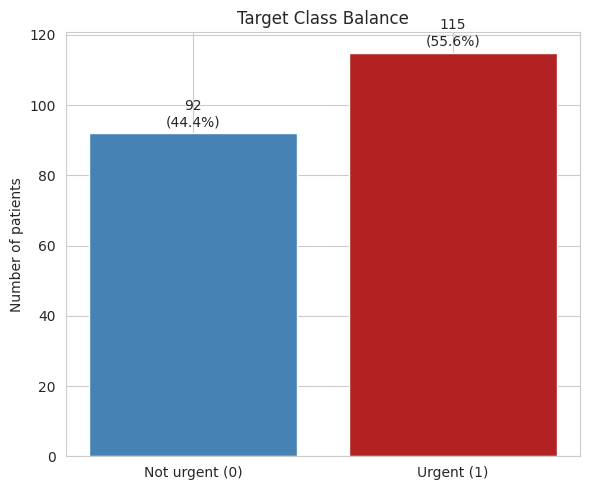

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
counts = df['is_urgent'].value_counts().sort_index()
bars = ax.bar(['Not urgent (0)', 'Urgent (1)'], counts.values,
              color=['steelblue', 'firebrick'])
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, count + 2,
            f'{count}\n({count/len(df)*100:.1f}%)', ha='center')
ax.set_title('Target Class Balance')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.savefig('target_balance.png', dpi=100, bbox_inches='tight')
plt.show()

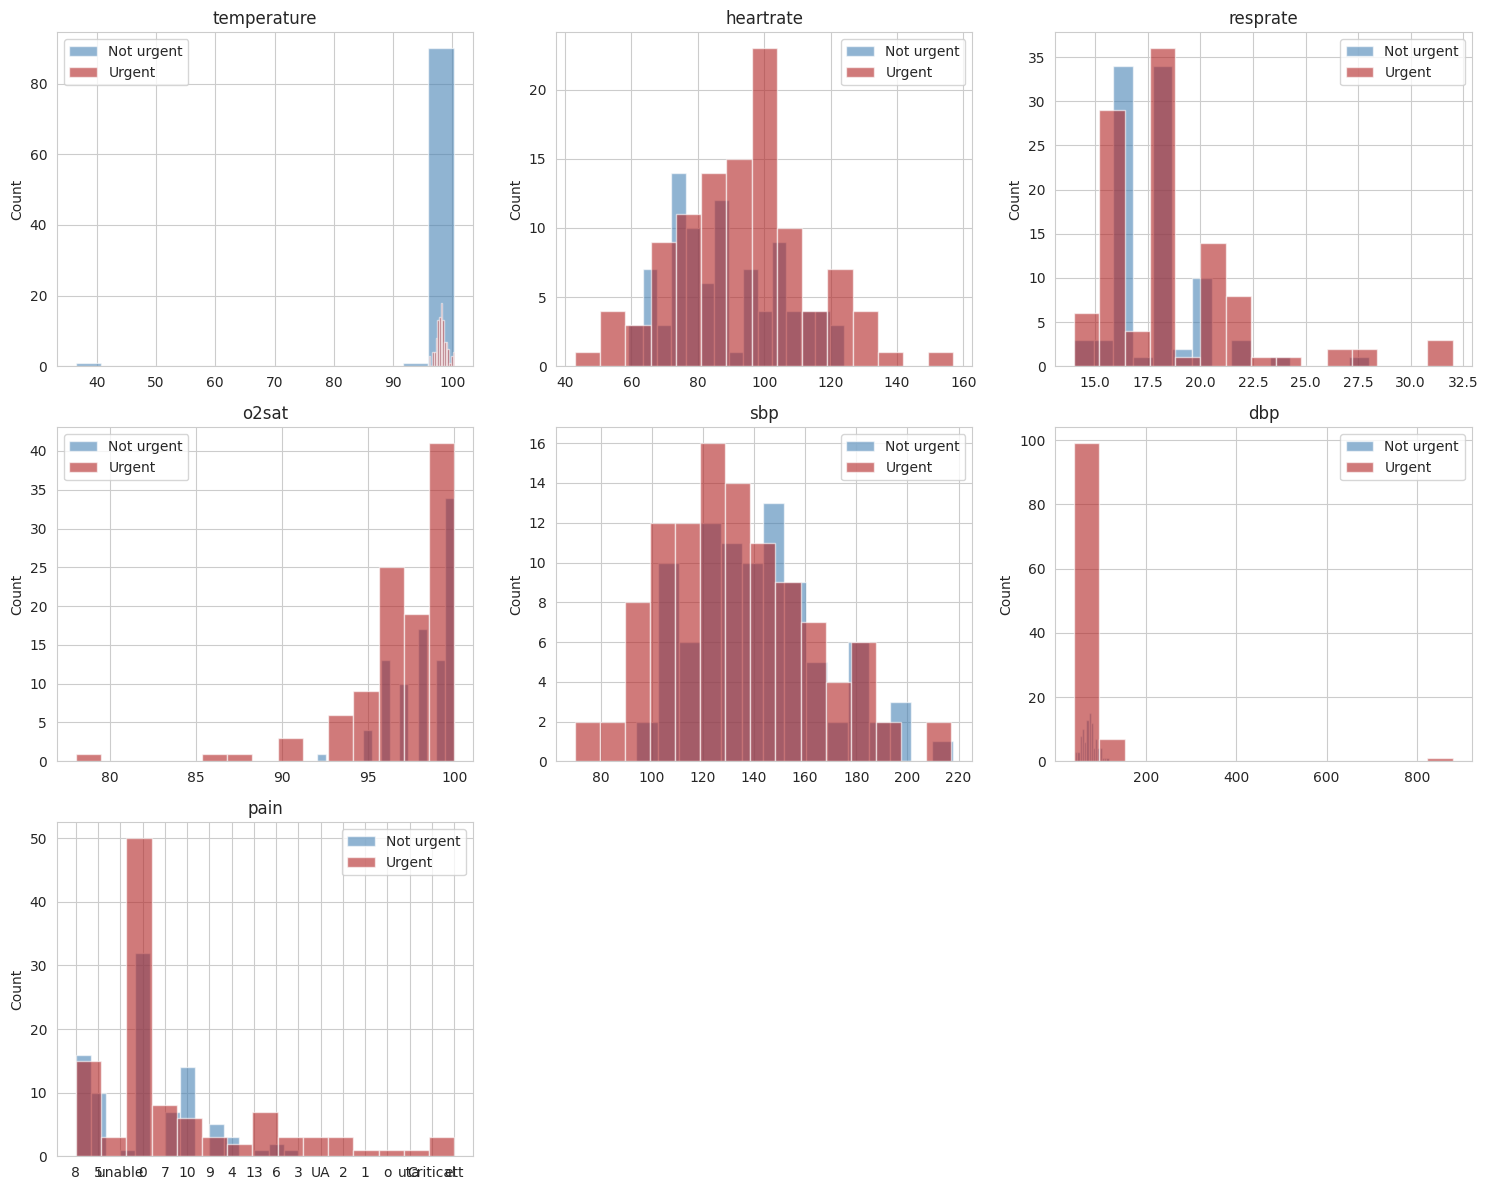

In [ ]:
vitals = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(vitals):
    for label, color, name in [(0, 'steelblue', 'Not urgent'),
                                (1, 'firebrick', 'Urgent')]:
        axes[i].hist(df[df['is_urgent'] == label][col].dropna(),
                     bins=15, alpha=0.6, color=color, label=name)
    axes[i].set_title(col)
    axes[i].legend()
    axes[i].set_ylabel('Count')

axes[-1].axis('off')
axes[-2].axis('off')
plt.tight_layout()
plt.savefig('vitals_by_class.png', dpi=100, bbox_inches='tight')
plt.show()

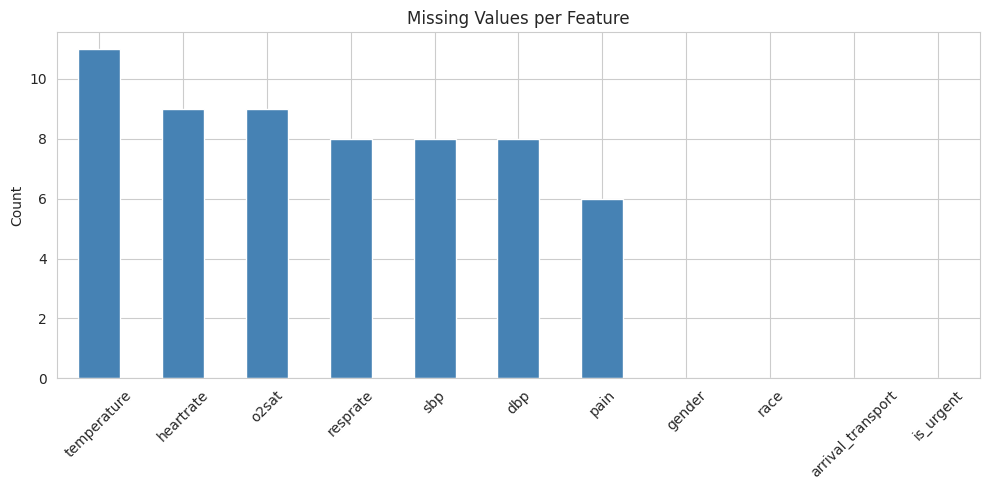

In [ ]:
plt.figure(figsize=(10, 5))
missing = df[vitals + ['gender', 'race', 'arrival_transport', 'is_urgent']].isna().sum()
missing = missing.sort_values(ascending=False)
missing.plot(kind='bar', color='steelblue')
plt.title('Missing Values per Feature')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 5: Leakage-Safe Preprocessing Pipeline

We split the data BEFORE any preprocessing, then fit imputation, scaling,
and encoding inside a scikit-learn Pipeline that only sees the training split.

Numeric features: impute with median, then standardise.
Categorical features: impute with most frequent, then one-hot encode.

In [ ]:
feature_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp',
                'pain', 'gender', 'race', 'arrival_transport']
target_col = 'is_urgent'

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTrain balance:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest balance:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 165 samples
Test set:     42 samples

Train balance:
is_urgent
1    0.558
0    0.442
Name: proportion, dtype: float64

Test balance:
is_urgent
1    0.548
0    0.452
Name: proportion, dtype: float64


In [ ]:
numeric_features = ['temperature', 'heartrate', 'resprate', 'o2sat',
                    'sbp', 'dbp']
categorical_features = ['pain', 'gender', 'race', 'arrival_transport']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessor ready.")

Preprocessor ready.


In [ ]:
models = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':         DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print(f"Models: {list(models.keys())}")

Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


In [ ]:
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'model':     pipe
    }

    print(f"{name}")
    print(f"  Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"  Precision: {results[name]['precision']:.4f}")
    print(f"  Recall:    {results[name]['recall']:.4f}")
    print(f"  F1:        {results[name]['f1']:.4f}")
    print()

Logistic Regression
  Accuracy:  0.5952
  Precision: 0.6667
  Recall:    0.5217
  F1:        0.5854

Decision Tree
  Accuracy:  0.5952
  Precision: 0.6364
  Recall:    0.6087
  F1:        0.6222

Random Forest
  Accuracy:  0.5714
  Precision: 0.6471
  Recall:    0.4783
  F1:        0.5500

Gradient Boosting
  Accuracy:  0.5952
  Precision: 0.6875
  Recall:    0.4783
  F1:        0.5641



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = {'mean': scores.mean(), 'std': scores.std(),
                        'scores': scores}
    print(f"{name:<25} CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"  Folds: {[f'{s:.3f}' for s in scores]}\n")

Logistic Regression       CV F1 = 0.6827 ± 0.0518
  Folds: ['0.611', '0.667', '0.769', '0.700', '0.667']

Decision Tree             CV F1 = 0.6331 ± 0.0811
  Folds: ['0.737', '0.650', '0.500', '0.684', '0.595']

Random Forest             CV F1 = 0.7194 ± 0.1043
  Folds: ['0.800', '0.514', '0.750', '0.750', '0.783']

Gradient Boosting         CV F1 = 0.6823 ± 0.0814
  Folds: ['0.769', '0.562', '0.703', '0.615', '0.762']



In [ ]:
comparison = pd.DataFrame({
    'Model':        list(results.keys()),
    'CV F1 Mean':   [cv_results[m]['mean'] for m in results],
    'CV F1 Std':    [cv_results[m]['std']  for m in results],
    'Test F1':      [results[m]['f1']      for m in results],
    'Test Accuracy':[results[m]['accuracy'] for m in results]
}).round(4).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)

print(comparison.to_string(index=False))
comparison.to_csv('urgency_model_comparison.csv', index=False)

              Model  CV F1 Mean  CV F1 Std  Test F1  Test Accuracy
      Random Forest      0.7194     0.1043   0.5500         0.5714
Logistic Regression      0.6827     0.0518   0.5854         0.5952
  Gradient Boosting      0.6823     0.0814   0.5641         0.5952
      Decision Tree      0.6331     0.0811   0.6222         0.5952


In [ ]:
# Tune Logistic Regression
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
lr_grid = GridSearchCV(lr_pipe,
    {'classifier__C': [0.01, 0.1, 1.0, 10.0],
     'classifier__penalty': ['l1', 'l2'],
     'classifier__solver': ['liblinear']},
    cv=cv, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)
print("LR best:", lr_grid.best_params_, "| CV F1:", round(lr_grid.best_score_, 4))

# Tune Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
rf_grid = GridSearchCV(rf_pipe,
    {'classifier__n_estimators': [50, 100, 200],
     'classifier__max_depth': [3, 5, None]},
    cv=cv, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("RF best:", rf_grid.best_params_, "| CV F1:", round(rf_grid.best_score_, 4))

LR best: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'} | CV F1: 0.7069
RF best: {'classifier__max_depth': 5, 'classifier__n_estimators': 100} | CV F1: 0.7361


In [ ]:
# Pick the better of the two tuned models
if rf_grid.best_score_ > lr_grid.best_score_:
    best_model = rf_grid.best_estimator_
    best_name = "Tuned Random Forest"
    best_cv = rf_grid.best_score_
else:
    best_model = lr_grid.best_estimator_
    best_name = "Tuned Logistic Regression"
    best_cv = lr_grid.best_score_

print(f"Selected: {best_name} | CV F1: {best_cv:.4f}")

# Save
joblib.dump(best_model, 'urgency_model.joblib')
print("Model saved to urgency_model.joblib")

# Verify
loaded = joblib.load('urgency_model.joblib')
sample_pred = loaded.predict(X_test.iloc[:3])
print(f"\nSample predictions: {sample_pred}")
print(f"Actual:             {y_test.iloc[:3].values}")

Selected: Tuned Random Forest | CV F1: 0.7361
Model saved to urgency_model.joblib

Sample predictions: [0 0 1]
Actual:             [1 1 1]


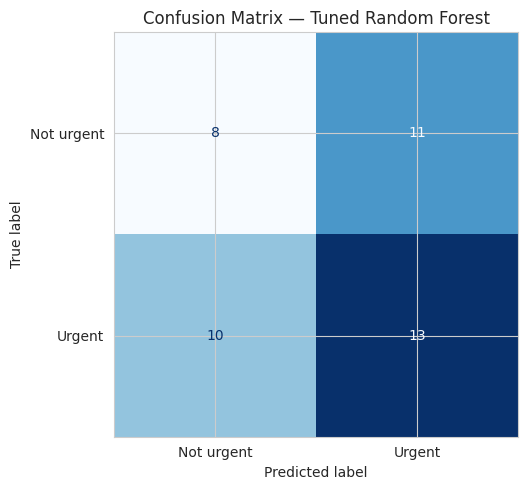


Performance by gender:
  F: n= 28 | accuracy=0.464
  M: n= 14 | accuracy=0.571

Performance by arrival transport:
  AMBULANCE: n= 18 | accuracy=0.389
  UNKNOWN: n=  3 | accuracy=0.667
  WALK IN: n= 20 | accuracy=0.550


In [ ]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Not urgent', 'Urgent']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Subgroup by gender
analysis = X_test.copy()
analysis['actual'] = y_test.values
analysis['predicted'] = y_pred_best
analysis['correct'] = (analysis['actual'] == analysis['predicted']).astype(int)

print("\nPerformance by gender:")
for g in sorted(analysis['gender'].dropna().unique()):
    sub = analysis[analysis['gender'] == g]
    print(f"  {g}: n={len(sub):>3} | accuracy={sub['correct'].mean():.3f}")

print("\nPerformance by arrival transport:")
for t in sorted(analysis['arrival_transport'].dropna().unique()):
    sub = analysis[analysis['arrival_transport'] == t]
    if len(sub) >= 3:
        print(f"  {t}: n={len(sub):>3} | accuracy={sub['correct'].mean():.3f}")

## Interpretation

**Model comparison:** [Which model won, by how much?]

**Cross-validation stability:** [Which model had the smallest std?]

**Subgroup performance:** [Any groups with noticeably worse performance?]

**Limitations:** With only 222 ED visits and a 41-patient test set, all
estimates carry wide uncertainty. Subgroup comparisons in particular rest on
small sample sizes and should be treated as flags for further investigation,
not as conclusions.